# E-Commerce EDA & Data Cleaning
## Python / Pandas Analysis

**Dataset:** Superstore Sales Data  
**Records:** 9,994 transactions  
**Period:** 2014 to 2017  
**Tools:** Python, Pandas, Matplotlib, Seaborn

**Objective:** Clean and explore retail sales data to 
surface category-level pricing patterns and 
sales distribution trends.

---

In [85]:
import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Basic charts
import seaborn as sns        # Beautiful charts
import warnings
warnings.filterwarnings('ignore')  # Hide minor warnings

# Make charts look bigger and cleaner
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully")

All libraries imported successfully


In [86]:
# Load the dataset
df = pd.read_excel('Superstore.xlsx')

# Show basic information immediately
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


---
## Section 1: Data Profiling
*Understanding the structure and content of our dataset before any analysis.*

In [87]:
# How does our data look?
print("=== FIRST 3 ROWS ===")
print(df.head(3))
print("\n=== LAST 3 ROWS ===")
print(df.tail(3))
print("\n=== DATASET DIMENSIONS ===")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

=== FIRST 3 ROWS ===
   Row ID        Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16  Second Class    DV-13045   

     Customer Name    Segment        Country         City  ... Postal Code  \
0      Claire Gute   Consumer  United States    Henderson  ...       42420   
1      Claire Gute   Consumer  United States    Henderson  ...       42420   
2  Darrin Van Huff  Corporate  United States  Los Angeles  ...       90036   

   Region       Product ID         Category Sub-Category  \
0   South  FUR-BO-10001798        Furniture    Bookcases   
1   South  FUR-CH-10000454        Furniture       Chairs   
2    West  OFF-LA-10000240  Office Supplies       Labels   

                                        Product Name   Sales  Quantity  \
0                  Bush Somerset Collectio

In [88]:
print("=== DATA TYPES OF EACH COLUMN ===")
print(df.dtypes)

=== DATA TYPES OF EACH COLUMN ===
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [89]:
print("=== NULL VALUE CHECK ===")
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

null_report = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percent.round(2)
})

# Only show columns that actually have nulls
print(null_report[null_report['Null Count'] > 0])

if null_report['Null Count'].sum() == 0:
    print("No null values found in any column.")

=== NULL VALUE CHECK ===
Empty DataFrame
Columns: [Null Count, Null Percentage]
Index: []
No null values found in any column.


In [90]:
print("=== DUPLICATE CHECK ===")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated()].head())

=== DUPLICATE CHECK ===
Number of duplicate rows: 0


In [91]:
print("=== STATISTICAL SUMMARY OF NUMERIC COLUMNS ===")
print(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2))

=== STATISTICAL SUMMARY OF NUMERIC COLUMNS ===
          Sales  Quantity  Discount   Profit
count   9994.00   9994.00   9994.00  9994.00
mean     229.86      3.79      0.16    28.66
std      623.25      2.23      0.21   234.26
min        0.44      1.00      0.00 -6599.98
25%       17.28      2.00      0.00     1.73
50%       54.49      3.00      0.20     8.67
75%      209.94      5.00      0.20    29.36
max    22638.48     14.00      0.80  8399.98


---
## Section 2: Data Cleaning
*Fixing data quality issues found during profiling.*

In [92]:
# Check current date column types
print("Before fixing:", df['Order Date'].dtype, df['Ship Date'].dtype)

# Convert to proper datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("After fixing:", df['Order Date'].dtype, df['Ship Date'].dtype)

Before fixing: datetime64[us] datetime64[us]
After fixing: datetime64[us] datetime64[us]


In [93]:
# Create useful date columns from Order Date
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Days To Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

print("New columns added:")
print(df[['Order Date', 'Order Year', 'Order Month', 
          'Order Quarter', 'Days To Ship']].head())

New columns added:
  Order Date  Order Year  Order Month  Order Quarter  Days To Ship
0 2016-11-08        2016           11              4             3
1 2016-11-08        2016           11              4             3
2 2016-06-12        2016            6              2             4
3 2015-10-11        2015           10              4             7
4 2015-10-11        2015           10              4             7


In [94]:
# Record row count before
rows_before = len(df)

# Remove duplicates
df = df.drop_duplicates()

# Record row count after
rows_after = len(df)

print(f"Rows before deduplication: {rows_before}")
print(f"Rows after deduplication: {rows_after}")
print(f"Duplicate rows removed: {rows_before - rows_after}")

Rows before deduplication: 9994
Rows after deduplication: 9994
Duplicate rows removed: 0


In [95]:
# Check and fix numeric columns
print("Checking numeric columns...")

# Verify Sales, Profit, Discount are correct types
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# Round financial columns to 2 decimal places
df['Sales'] = df['Sales'].round(2)
df['Profit'] = df['Profit'].round(2)

print("After normalization:")
print(df[['Sales', 'Profit', 'Discount', 'Quantity']].dtypes)
print("\nSample values:")
print(df[['Sales', 'Profit', 'Discount']].head(3))

Checking numeric columns...
After normalization:
Sales       float64
Profit      float64
Discount    float64
Quantity      int64
dtype: object

Sample values:
    Sales  Profit  Discount
0  261.96   41.91       0.0
1  731.94  219.58       0.0
2   14.62    6.87       0.0


In [96]:
# Check again after cleaning
print("=== NULL CHECK AFTER CLEANING ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# If Sales has any nulls (from coerce above), fill with median
if df['Sales'].isnull().sum() > 0:
    median_sales = df['Sales'].median()
    df['Sales'].fillna(median_sales, inplace=True)
    print(f"Filled {df['Sales'].isnull().sum()} Sales nulls with median: {median_sales}")

# If Profit has any nulls
if df['Profit'].isnull().sum() > 0:
    df['Profit'].fillna(0, inplace=True)
    print("Filled Profit nulls with 0")

print("\nNull check after imputation:")
remaining_nulls = df.isnull().sum().sum()
print(f"Total remaining nulls: {remaining_nulls}")

=== NULL CHECK AFTER CLEANING ===
Series([], dtype: int64)

Null check after imputation:
Total remaining nulls: 0


In [97]:
print("=== CLEANING SUMMARY ===")
print(f"Final dataset shape: {df.shape}")
print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Total revenue: ${df['Sales'].sum():,.2f}")
print(f"Unique customers: {df['Customer ID'].nunique()}")
print(f"Unique products: {df['Product ID'].nunique()}")
print(f"Categories: {df['Category'].unique().tolist()}")
print("\nData is clean and ready for analysis.")

=== CLEANING SUMMARY ===
Final dataset shape: (9994, 26)
Date range: 2014-01-03 to 2017-12-30
Total revenue: $2,297,200.65
Unique customers: 793
Unique products: 1862
Categories: ['Furniture', 'Office Supplies', 'Technology']

Data is clean and ready for analysis.


---
## Section 3: Exploratory Data Analysis
*6 visualizations revealing pricing patterns and sales distribution trends.*

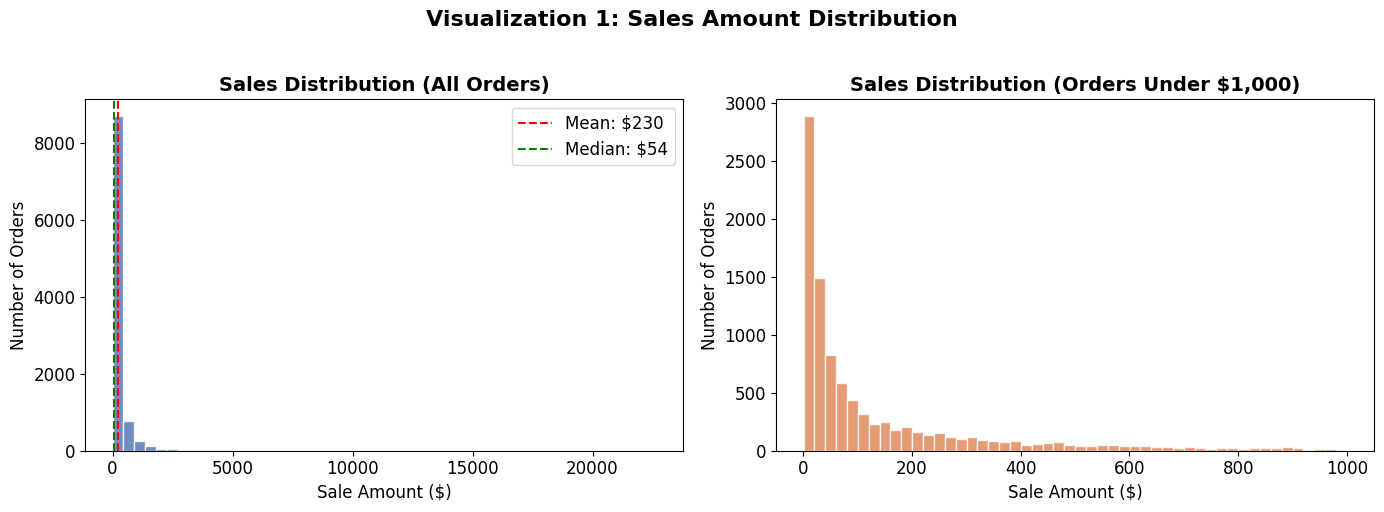


Key Insight: Most orders are under $500.
Mean sale: $229.86 vs Median: $54.49
Mean is higher than median, confirming right-skewed distribution — a few large orders pull the average up.


In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: Full distribution
axes[0].hist(df['Sales'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].set_title('Sales Distribution (All Orders)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sale Amount ($)')
axes[0].set_ylabel('Number of Orders')
axes[0].axvline(df['Sales'].mean(), color='red', linestyle='--', 
                label=f'Mean: ${df["Sales"].mean():.0f}')
axes[0].axvline(df['Sales'].median(), color='green', linestyle='--',
                label=f'Median: ${df["Sales"].median():.0f}')
axes[0].legend()

# Right chart: Orders below $1000 (zoomed in for clarity)
small_orders = df[df['Sales'] < 1000]['Sales']
axes[1].hist(small_orders, bins=50, color='#DD8452', edgecolor='white', alpha=0.8)
axes[1].set_title('Sales Distribution (Orders Under $1,000)', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sale Amount ($)')
axes[1].set_ylabel('Number of Orders')

plt.suptitle('Visualization 1: Sales Amount Distribution', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz1_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: Most orders are under $500.")
print(f"Mean sale: ${df['Sales'].mean():.2f} vs Median: ${df['Sales'].median():.2f}")
print("Mean is higher than median, confirming right-skewed distribution — a few large orders pull the average up.")

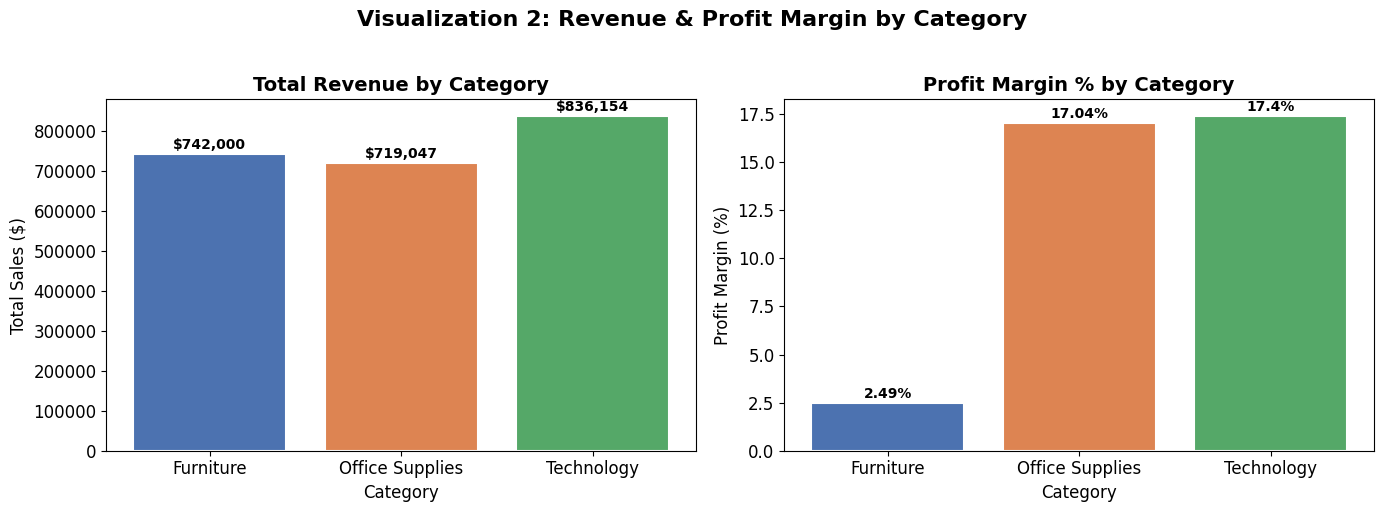


Key Insight:
       Category  Total_Sales  Profit_Margin
      Furniture    741999.73           2.49
Office Supplies    719046.90          17.04
     Technology    836154.02          17.40


In [99]:
# Calculate category totals
category_stats = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Orders=('Order ID', 'count'),
    Avg_Sale=('Sales', 'mean'),
    Total_Profit=('Profit', 'sum')
).round(2).reset_index()

category_stats['Profit_Margin'] = (
    category_stats['Total_Profit'] / category_stats['Total_Sales'] * 100
).round(2)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#DD8452', '#55A868']

# Left: Total Revenue
bars1 = axes[0].bar(category_stats['Category'], 
                     category_stats['Total_Sales'],
                     color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Total Revenue by Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_xlabel('Category')

for bar, val in zip(bars1, category_stats['Total_Sales']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right: Profit Margin
bars2 = axes[1].bar(category_stats['Category'],
                     category_stats['Profit_Margin'],
                     color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Profit Margin % by Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].set_xlabel('Category')

for bar, val in zip(bars2, category_stats['Profit_Margin']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Visualization 2: Revenue & Profit Margin by Category',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz2_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight:")
print(category_stats[['Category', 'Total_Sales', 'Profit_Margin']].to_string(index=False))

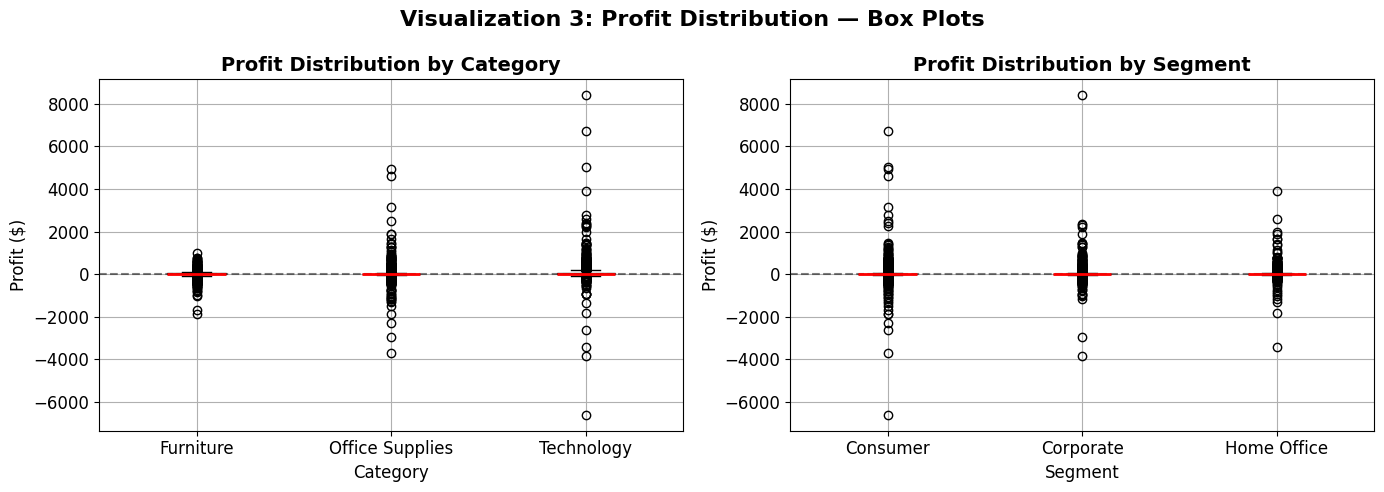


Key Insight: 1871 orders (18.7%) are loss-making.
Worst loss in one order: $-6599.98
Best profit in one order: $8399.98


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Box plot by category
df.boxplot(column='Profit', by='Category', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Profit Distribution by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Profit ($)')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Break Even')

# Right: Box plot by segment  
df.boxplot(column='Profit', by='Segment', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#DD8452', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Profit Distribution by Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Profit ($)')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.suptitle('Visualization 3: Profit Distribution — Box Plots',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_profit_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Count loss-making orders
loss_orders = df[df['Profit'] < 0]
print(f"\nKey Insight: {len(loss_orders)} orders ({len(loss_orders)/len(df)*100:.1f}%) "
      f"are loss-making.")
print(f"Worst loss in one order: ${df['Profit'].min():.2f}")
print(f"Best profit in one order: ${df['Profit'].max():.2f}")

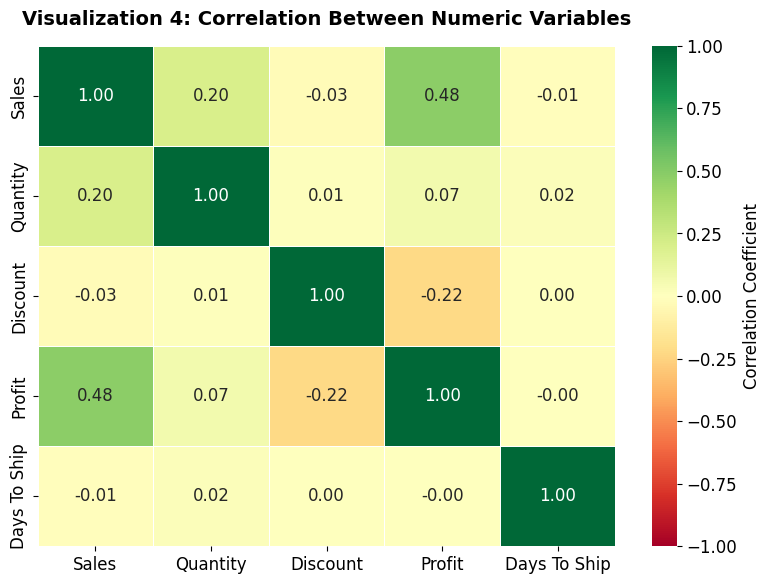


Key Correlation Insights:
Discount vs Profit correlation: -0.22
Negative correlation — discounts tend to reduce profit


In [101]:
# Select numeric columns
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Days To Ship']
correlation_matrix = df[numeric_cols].corr().round(2)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Visualization 4: Correlation Between Numeric Variables',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('viz4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Correlation Insights:")
disc_profit_corr = correlation_matrix.loc['Discount', 'Profit']
print(f"Discount vs Profit correlation: {disc_profit_corr:.2f}")
if disc_profit_corr < -0.3:
    print("Strong negative correlation — higher discounts clearly reduce profit")
elif disc_profit_corr < 0:
    print("Negative correlation — discounts tend to reduce profit")

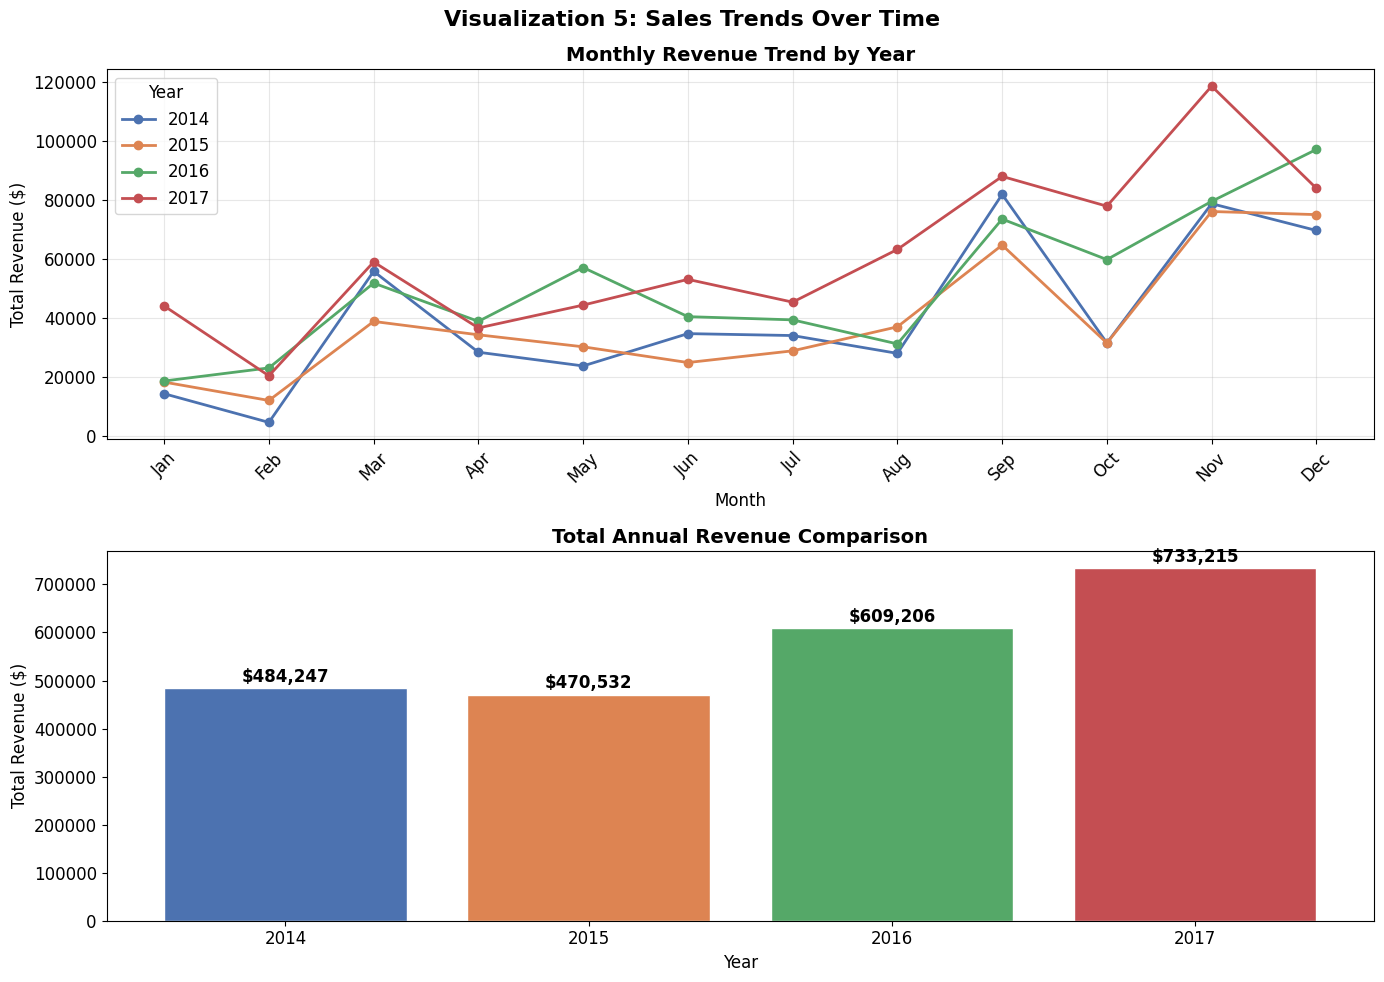


Key Insight: Revenue grew 51.4% from 2014 to 2017


In [102]:
# Group by year and month
monthly_sales = df.groupby(['Order Year', 'Order Month', 'Order Month Name']).agg(
    Revenue=('Sales', 'sum'),
    Orders=('Order ID', 'count'),
    Avg_Sale=('Sales', 'mean')
).round(2).reset_index()

monthly_sales = monthly_sales.sort_values(['Order Year', 'Order Month'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top chart: Revenue by month for each year
colors_years = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, year in enumerate(sorted(df['Order Year'].unique())):
    year_data = monthly_sales[monthly_sales['Order Year'] == year]
    axes[0].plot(year_data['Order Month Name'], year_data['Revenue'],
                marker='o', linewidth=2, markersize=6,
                label=str(year), color=colors_years[i])

axes[0].set_title('Monthly Revenue Trend by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].legend(title='Year')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Bottom chart: Year over year total comparison
yearly_totals = df.groupby('Order Year')['Sales'].sum().reset_index()
bars = axes[1].bar(yearly_totals['Order Year'].astype(str),
                   yearly_totals['Sales'],
                   color=colors_years, edgecolor='white')
axes[1].set_title('Total Annual Revenue Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Revenue ($)')

for bar, val in zip(bars, yearly_totals['Sales']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Visualization 5: Sales Trends Over Time',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Growth calculation
if len(yearly_totals) >= 2:
    first_year = yearly_totals['Sales'].iloc[0]
    last_year = yearly_totals['Sales'].iloc[-1]
    growth = ((last_year - first_year) / first_year * 100)
    print(f"\nKey Insight: Revenue grew {growth:.1f}% from "
          f"{yearly_totals['Order Year'].iloc[0]} to "
          f"{yearly_totals['Order Year'].iloc[-1]}")

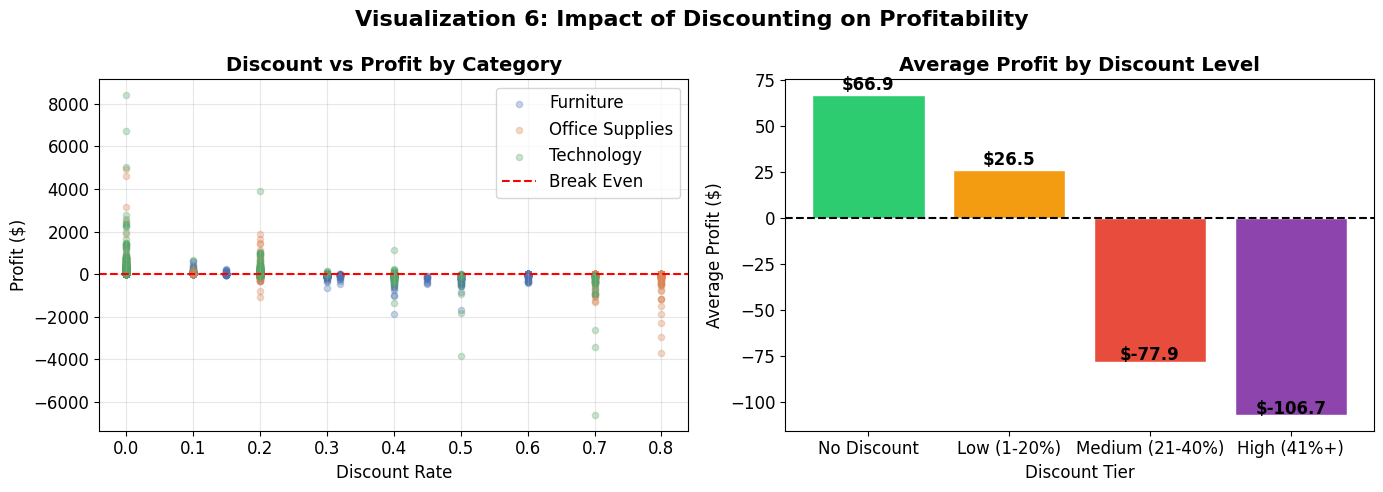


Key Insight: Average profit by discount tier:
Discount Tier
No Discount         66.90
Low (1-20%)         26.50
Medium (21-40%)    -77.86
High (41%+)       -106.71


In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Discount vs Profit — all points
category_colors = {'Furniture': '#4C72B0', 
                   'Office Supplies': '#DD8452', 
                   'Technology': '#55A868'}

for category, color in category_colors.items():
    mask = df['Category'] == category
    axes[0].scatter(df[mask]['Discount'], df[mask]['Profit'],
                   alpha=0.3, c=color, label=category, s=20)

axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Break Even')
axes[0].set_title('Discount vs Profit by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Profit ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Average profit by discount tier
df['Discount Tier'] = pd.cut(df['Discount'],
                              bins=[-0.01, 0.001, 0.2, 0.4, 1.0],
                              labels=['No Discount', 'Low (1-20%)', 
                                      'Medium (21-40%)', 'High (41%+)'])

discount_profit = df.groupby('Discount Tier', observed=True)['Profit'].mean().round(2)

colors_discount = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
bars = axes[1].bar(discount_profit.index, discount_profit.values,
                   color=colors_discount, edgecolor='white')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Average Profit by Discount Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Discount Tier')
axes[1].set_ylabel('Average Profit ($)')

for bar, val in zip(bars, discount_profit.values):
    ypos = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 1.5
    axes[1].text(bar.get_x() + bar.get_width()/2, ypos,
                f'${val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Visualization 6: Impact of Discounting on Profitability',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('viz6_discount_profit.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: Average profit by discount tier:")
print(discount_profit.to_string())

---
## Section 4: Findings Summary
*Business observations from the analysis — translated into plain English.*

In [104]:
print("=" * 60)
print("BUSINESS FINDINGS SUMMARY")
print("E-Commerce Sales Analysis — 2014 to 2017")
print("=" * 60)

print("\n1. SALES DISTRIBUTION")
print(f"   Most orders are small — median order value is "
      f"${df['Sales'].median():.0f}")
print(f"   but mean is ${df['Sales'].mean():.0f} due to a few very large orders.")
print("   RECOMMENDATION: Focus marketing on increasing order frequency")
print("   rather than order size — most customers buy small amounts often.")

print("\n2. CATEGORY PERFORMANCE")
tech_margin = df[df['Category']=='Technology']['Profit'].sum() / \
              df[df['Category']=='Technology']['Sales'].sum() * 100
furn_margin = df[df['Category']=='Furniture']['Profit'].sum() / \
              df[df['Category']=='Furniture']['Sales'].sum() * 100
print(f"   Technology: Highest revenue AND best margin ({tech_margin:.1f}%)")
print(f"   Furniture: High revenue but dangerously low margin ({furn_margin:.1f}%)")
print("   RECOMMENDATION: Investigate furniture pricing and cost structure.")

print("\n3. DISCOUNT IMPACT")
no_disc = df[df['Discount']==0]['Profit'].mean()
high_disc = df[df['Discount']>0.4]['Profit'].mean()
print(f"   Orders with no discount average ${no_disc:.0f} profit")
print(f"   Orders with 40%+ discount average ${high_disc:.0f} profit")
print("   RECOMMENDATION: Set a maximum discount cap of 20%.")
print("   Discounts above this threshold consistently result in losses.")

print("\n4. LOSS-MAKING ORDERS")
loss_count = len(df[df['Profit'] < 0])
loss_pct = loss_count / len(df) * 100
print(f"   {loss_count} orders ({loss_pct:.1f}% of all orders) resulted in losses.")
print("   RECOMMENDATION: Audit high-discount orders in Furniture category.")
print("   Most losses occur where discounts exceed 40%.")

print("\n5. REVENUE GROWTH")
y2014 = df[df['Order Year']==2014]['Sales'].sum()
y2017 = df[df['Order Year']==2017]['Sales'].sum()
growth = (y2017 - y2014) / y2014 * 100
print(f"   Revenue grew {growth:.1f}% from 2014 to 2017.")
print("   RECOMMENDATION: Q4 is consistently the strongest quarter.")
print("   Increase inventory and staffing in October through December.")

print("\n" + "=" * 60)
print("Analysis complete. Dataset is clean and ready for dashboard use.")
print("=" * 60)

BUSINESS FINDINGS SUMMARY
E-Commerce Sales Analysis — 2014 to 2017

1. SALES DISTRIBUTION
   Most orders are small — median order value is $54
   but mean is $230 due to a few very large orders.
   RECOMMENDATION: Focus marketing on increasing order frequency
   rather than order size — most customers buy small amounts often.

2. CATEGORY PERFORMANCE
   Technology: Highest revenue AND best margin (17.4%)
   Furniture: High revenue but dangerously low margin (2.5%)
   RECOMMENDATION: Investigate furniture pricing and cost structure.

3. DISCOUNT IMPACT
   Orders with no discount average $67 profit
   Orders with 40%+ discount average $-107 profit
   RECOMMENDATION: Set a maximum discount cap of 20%.
   Discounts above this threshold consistently result in losses.

4. LOSS-MAKING ORDERS
   1871 orders (18.7% of all orders) resulted in losses.
   RECOMMENDATION: Audit high-discount orders in Furniture category.
   Most losses occur where discounts exceed 40%.

5. REVENUE GROWTH
   Revenue

In [105]:
# Save the cleaned dataset for use in Power BI or further analysis
df.to_csv('superstore_cleaned.csv', index=False)
df.to_excel('superstore_cleaned.xlsx', index=False)

print("Clean dataset exported successfully.")
print(f"Final shape: {df.shape}")
print("Files saved: superstore_cleaned.csv, superstore_cleaned.xlsx")

PermissionError: [Errno 13] Permission denied: 'superstore_cleaned.xlsx'